In [3]:
#Import Libraries

from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler

##Dimension reduction and clustering libraries
import umap
from umap import UMAP
import hdbscan
import sklearn.cluster as cluster
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import pairwise_distances
from scipy.spatial.distance import pdist


In [2]:
!pip install hdbscan
#!pip install umap-learn

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 42.2 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for hdbscan: filename=hdbscan-0.8.33-cp39-cp39-linux_x86_64.whl size=750908 sha256=625370cd5197c99aaa6f1c814bbfc2f49ff3925361607569abe086f7f44e702a
  Stored in directory: /home/agupta55/.cache/pip/wheels/28/5e/ed/5989da4cc423a222a47cbb4fde5d6c0eff4590d922e45f233c
Successfully built hdbscan


In [4]:
#preprocessing 
dF=pd.read_csv("./preprocessed.csv")

In [5]:
dF['Numbering'] = range(1, len(dF) + 1)

# Display the DataFrame with the new column
print(dF)

          Protein UniProtID  \
0     BC11A_HUMAN    Q9H165   
1     BC11B_HUMAN    Q9C0K0   
2      BCL6_HUMAN    P41182   
3     BCL6B_HUMAN    Q8N143   
4      CTCF_HUMAN    P49711   
...           ...       ...   
1336  ZC3H8_HUMAN    Q8N5P1   
1337  ZGPAT_HUMAN    Q8N5A5   
1338  SATB1_HUMAN    Q01826   
1339   COE2_HUMAN    Q9HAK2   
1340   COE3_HUMAN    Q9H4W6   

                                               Sequence  Total AminoAcids  \
0     MSRRKQGKPQHLSKREFSPEPLEAILTDDEPDHGPLGAPEGDHDLL...               835   
1     MSRRKQGNPQHLSQRELITPEADHVEAAILEEDEGLEIEEPSGLGL...               894   
2     MASPADSCIQFTRHASDVLLNLNRLRSRDILTDVVIVVSREQFRAH...               706   
3     MGSPAAPEGALGYVREFTRHSSDVLGNLNELRLRGILTDVTLLVGG...               479   
4     MEGDAVEAIVEESETFIKGKERKTYQRRREGGQEEDACHLPQNQTD...               727   
...                                                 ...               ...   
1336  MDFENLFSKPPNPALGKTATDSDERIDDEIDTEVEETQEEKIKLEC...               291   
1337  MDEES

In [255]:
#considering only numericmns_to_exclude = ['Normalized HP Score','Total AminoAcids','Net Charge','Hydropaticity','K fraction','R fraction','f-','f+','sum_of_total_fractions','Numbering','total_aminoacids_count','f-','|f+ - f-|']
numeric_dF = dF.select_dtypes(include='number')
columns_to_exclude = ['Total AminoAcids','Net Charge','Hydropaticity','K fraction','R fraction','f-','sum_of_total_fractions','Numbering','total_aminoacids_count']
df = numeric_dF.drop(columns=columns_to_exclude)
df.head()
print(df.shape)

(1341, 18)


## UMAP DIMESIONALITY REDUCTION CALCULATIONS

In [256]:
sns.set(style='white', context='poster', rc={'figure.figsize':(14,10)})

np.random.seed(42)
data_for_umap = df.values
X_scaled = StandardScaler().fit_transform(data_for_umap)

fit=umap.UMAP()
u = fit.fit_transform(X_scaled)

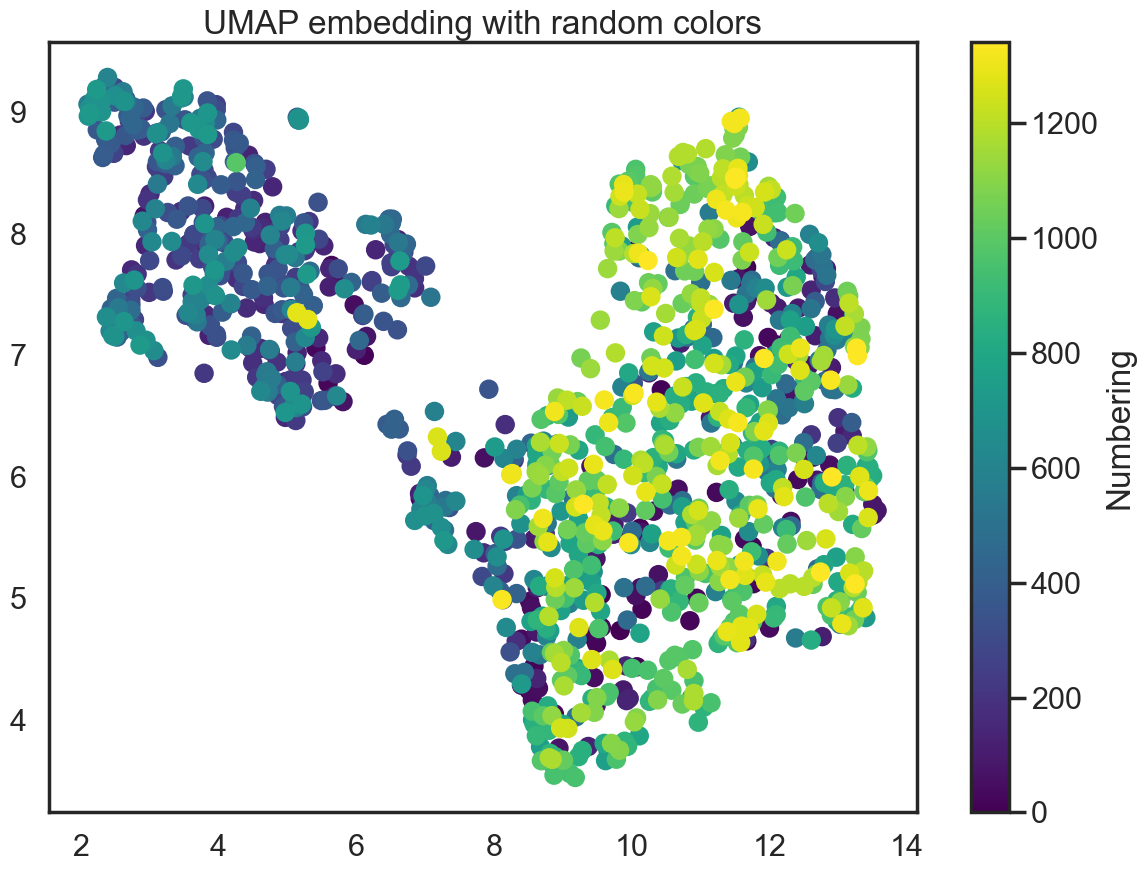

In [257]:
#PLOT UMAP RESULTS

color = df.index

plt.scatter(u[:,0],u[:,1],c=color,cmap='viridis')
plt.colorbar(label='Numbering')
plt.title('UMAP embedding with random colors')
plt.show()


In [258]:
#ADJUSTABLE RAND SCORE AND MUUAL INFO

features = df
true_labels = dF['Numbering']

def perform_umap_hdbscan(components, features):
    umap = UMAP(n_components=components,n_neighbors=50, min_dist=0.5,metric='euclidean')
    umap_result = umap.fit_transform(features)
    
    hdbscan_clusterer = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=5)
    hdbscan_labels = hdbscan_clusterer.fit_predict(umap_result)
    
    return hdbscan_labels

components_list = [2, 3, 4, 5, 6, 7, 8, 9, 10]

for components in components_list:
    umap_hdbscan_labels = perform_umap_hdbscan(components, features)
    
    adjusted_rand = adjusted_rand_score(true_labels, umap_hdbscan_labels)
    adjusted_mutual_info = adjusted_mutual_info_score(true_labels, umap_hdbscan_labels)
    
    print(f"UMAP Components: {components}, Adjusted Rand Score: {adjusted_rand}, Adjusted Mutual Info Score: {adjusted_mutual_info}")


UMAP Components: 2, Adjusted Rand Score: 0.0, Adjusted Mutual Info Score: 6.62911826088057e-15
UMAP Components: 3, Adjusted Rand Score: 0.0, Adjusted Mutual Info Score: 2.4102486832759414e-13
UMAP Components: 4, Adjusted Rand Score: 0.0, Adjusted Mutual Info Score: -3.577862113182803e-13
UMAP Components: 5, Adjusted Rand Score: 0.0, Adjusted Mutual Info Score: -9.70622388929561e-14
UMAP Components: 6, Adjusted Rand Score: 0.0, Adjusted Mutual Info Score: -5.382601725159272e-14
UMAP Components: 7, Adjusted Rand Score: 0.0, Adjusted Mutual Info Score: -4.692477210239529e-13
UMAP Components: 8, Adjusted Rand Score: 0.0, Adjusted Mutual Info Score: -4.0855266243948145e-13
UMAP Components: 9, Adjusted Rand Score: 0.0, Adjusted Mutual Info Score: -1.3528244327128336e-13
UMAP Components: 10, Adjusted Rand Score: 0.0, Adjusted Mutual Info Score: 1.3048319959786259e-13


In [259]:
unique_labels = np.unique(hdbscan_labels)
print(f"Unique Labels: {unique_labels}")

Unique Labels: [0 1]


In [260]:
df.shape

(1341, 18)

In [261]:


# Vary the number of UMAP components
n_components = [2, 3, 4, 5, 6, 7, 8, 9, 10]

for n_components in umap_components:
    # Instantiate UMAP model
    umap_model = umap.UMAP(n_components=n_components, n_neighbors=50, min_dist=0.0, metric='euclidean', random_state=42)

    # Fit and transform the scaled data
    umap_result = umap_model.fit_transform(scaled_df)

    # HDBSCAN for clustering
    hdbscan_clusterer = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=5)
    hdbscan_labels = hdbscan_clusterer.fit_predict(umap_result)

    #Rand Index
    rand_index = adjusted_rand_score(true_labels, hdbscan_labels)

    #noise percentage
    noise_percentage = np.sum(hdbscan_labels == -1) / len(hdbscan_labels)

    print(f"UMAP Components: {n_components}, Rand Index: {rand_index}, Noise Percentage: {noise_percentage}")

/Users/pritheekakarla/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


UMAP Components: 2, Rand Index: 0.0, Noise Percentage: 0.08650260999254288


/Users/pritheekakarla/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


UMAP Components: 3, Rand Index: 0.0, Noise Percentage: 0.10067114093959731


/Users/pritheekakarla/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


...

UMAP Components: 8, Rand Index: 0.0, Noise Percentage: 0.002982848620432513


/Users/pritheekakarla/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


UMAP Components: 9, Rand Index: 0.0, Noise Percentage: 0.0037285607755406414


/Users/pritheekakarla/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


UMAP Components: 10, Rand Index: 0.0, Noise Percentage: 0.006711409395973154


## UMAP-HBSCAN clustering hyper-parameters tuning

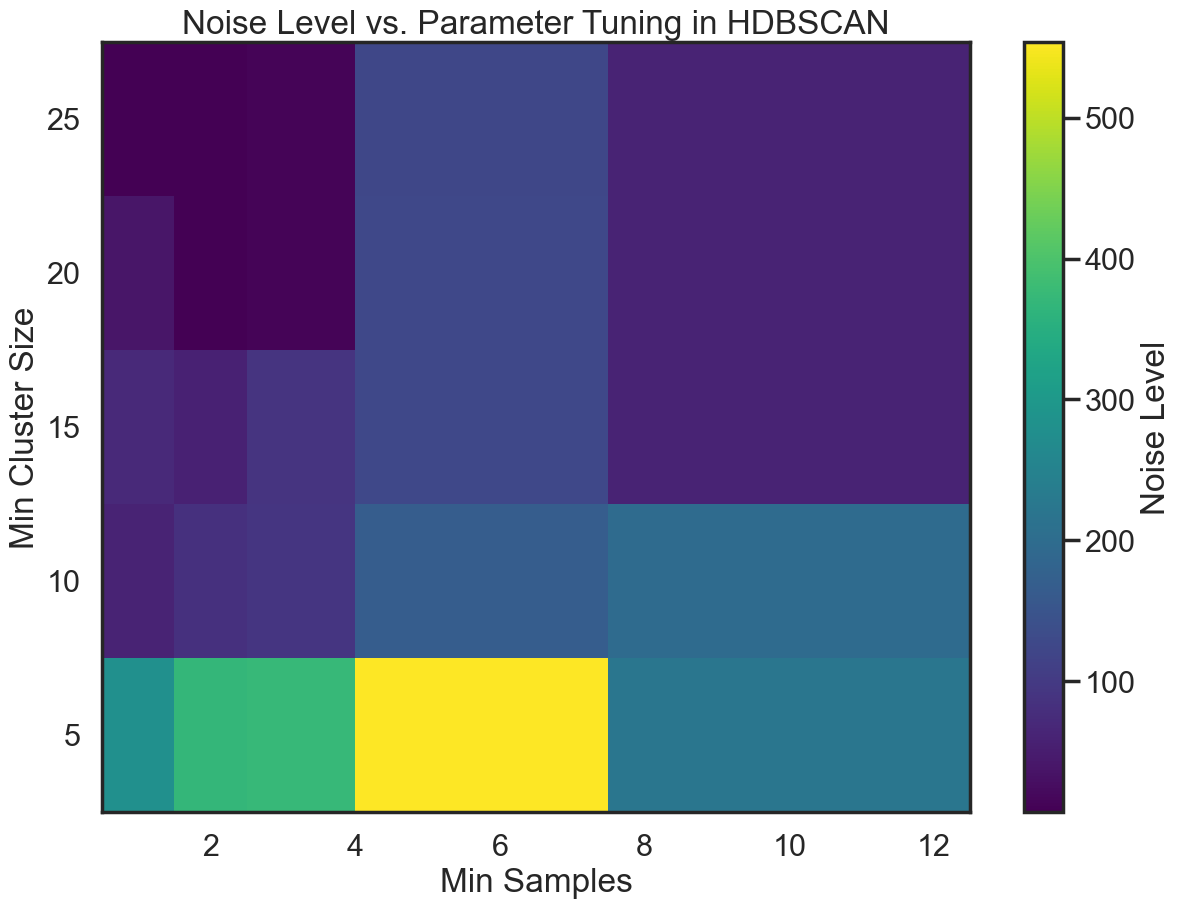

In [262]:
# UMAP with 5 components
umap_model = umap.UMAP(n_components=5)
umap_embeddings = umap_model.fit_transform(scaled_df)

# Varying parameters for HDBSCAN
min_cluster_sizes = [5, 10, 15, 20, 25]
min_samples_values = [1, 2, 3, 5, 10]

# Initialize arrays to store noise levels
noise_levels = np.zeros((len(min_cluster_sizes), len(min_samples_values)))

# Loop through parameter combinations
for i, min_cluster_size in enumerate(min_cluster_sizes):
    for j, min_samples in enumerate(min_samples_values):
        hdbscan_clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples)
        hdbscan_labels = hdbscan_clusterer.fit_predict(umap_embeddings)
        
        # Count the number of points labeled as noise (-1)
        noise_levels[i, j] = np.sum(hdbscan_labels == -1)

# Plot the noise levels
fig, ax = plt.subplots()
c = ax.pcolormesh(min_samples_values, min_cluster_sizes, noise_levels, cmap='viridis', shading='auto')
fig.colorbar(c, label='Noise Level')
ax.set_xlabel('Min Samples')
ax.set_ylabel('Min Cluster Size')
ax.set_title('Noise Level vs. Parameter Tuning in HDBSCAN')
plt.show()

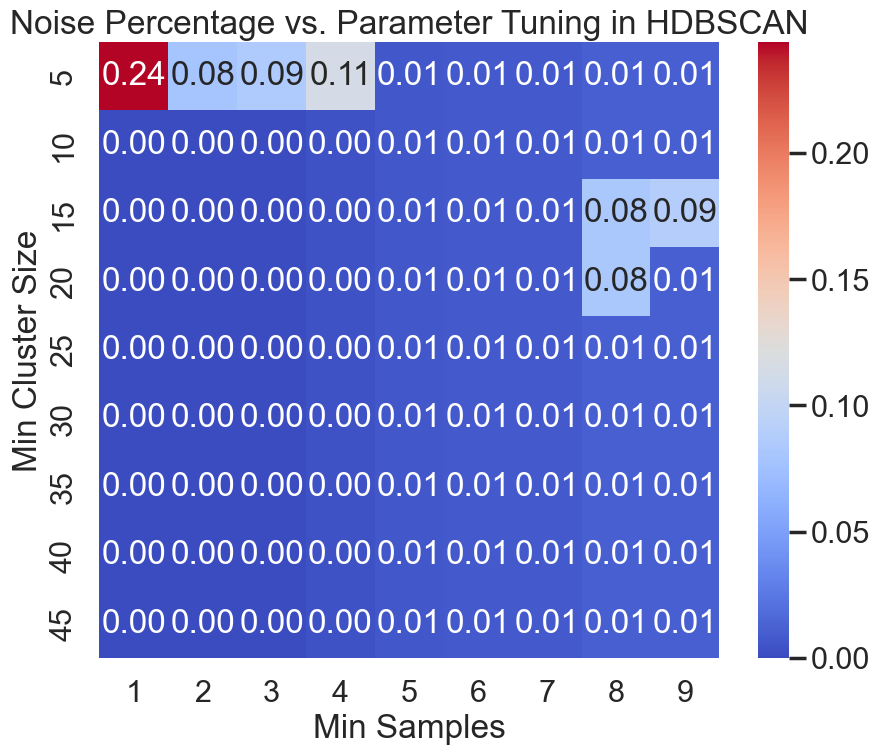

In [263]:
#df is data
scaler = StandardScaler()
scaled_df = scaler.fit_transform(df)

# UMAP with 5 components
umap_model = umap.UMAP(n_components=5, min_dist=0.0, n_neighbors=50, metric='euclidean')
umap_embeddings = umap_model.fit_transform(scaled_df)

#a DataFrame to store results
results = pd.DataFrame(columns=['min_cluster_size', 'min_samples', 'noise_percentage'])

# Parameter tuning
min_cluster_size_range = range(5, 50, 5)
min_samples_range = range(1, 10)

for min_cluster_size in min_cluster_size_range:
    for min_samples in min_samples_range:
        # HDBSCAN with parameter tuning
        hdbscan_clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples)
        hdbscan_labels = hdbscan_clusterer.fit_predict(umap_embeddings)

        # Calculate noise level (percentage of points labeled as noise)
        noise_percentage = np.sum(hdbscan_labels == -1) / len(hdbscan_labels)

        # Append results to the DataFrame
        results = pd.concat([results, pd.DataFrame({'min_cluster_size': [min_cluster_size],
                                                     'min_samples': [min_samples],
                                                     'noise_percentage': [noise_percentage]})], ignore_index=True)

# Convert 'noise_percentage' to numeric
results['noise_percentage'] = pd.to_numeric(results['noise_percentage'])

# Reshape the DataFrame for the correlation matrix
corr_data = results.pivot_table(index='min_cluster_size', columns='min_samples', values='noise_percentage', aggfunc='mean')

# Plotting the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_data, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Noise Percentage vs. Parameter Tuning in HDBSCAN')
plt.xlabel('Min Samples')
plt.ylabel('Min Cluster Size')
plt.show()


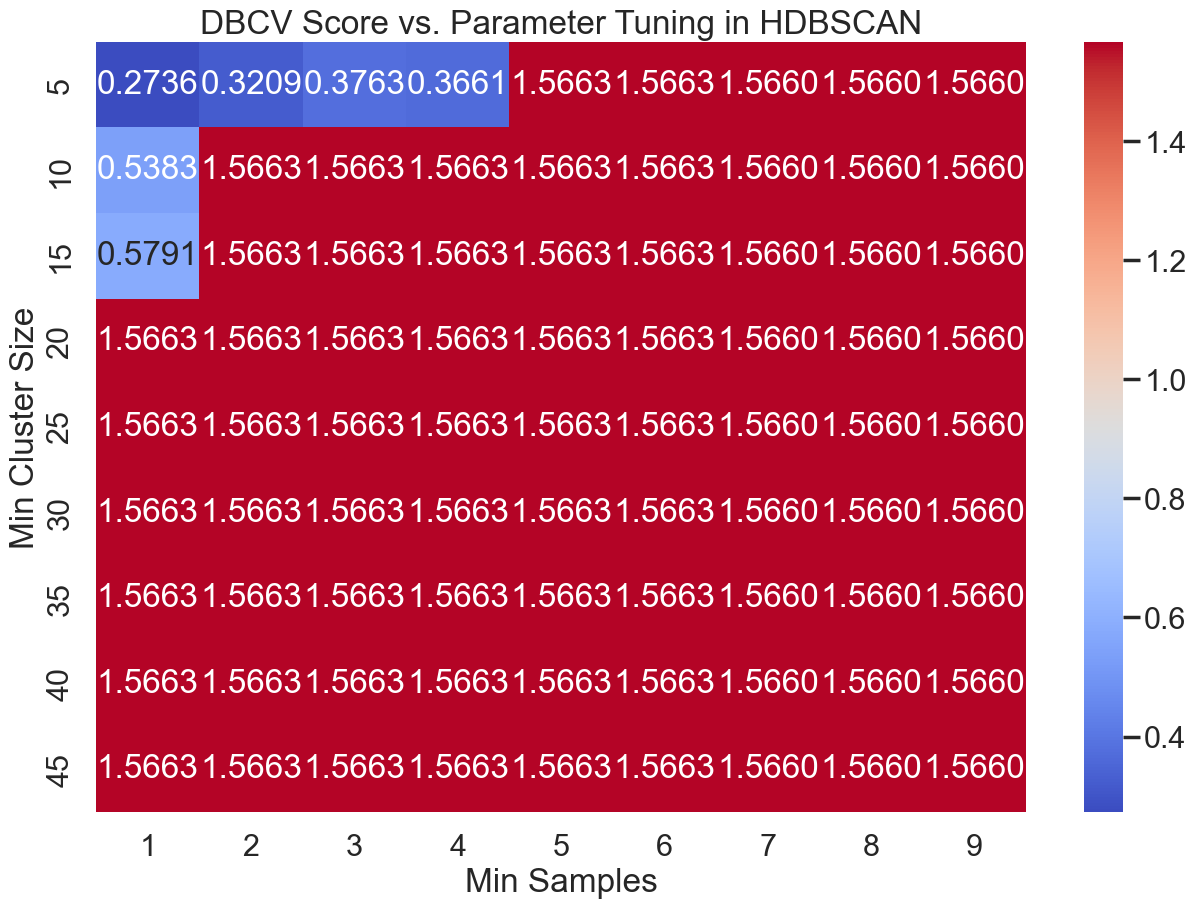

In [264]:
#df is your data
scaler = StandardScaler()
scaled_df = scaler.fit_transform(df)

# UMAP with 5 components
umap_model = umap.UMAP(n_components=5,min_dist=0.0,n_neighbors=50,metric='euclidean')
umap_embeddings = umap_model.fit_transform(scaled_df)

def calculate_dbcv(embeddings, labels):
    distances = pairwise_distances(embeddings, metric='euclidean')
    mean_intra_cluster_distances = []

    for cluster_label in np.unique(labels):
        cluster_indices = np.where(labels == cluster_label)[0]
        if len(cluster_indices) > 1:
            cluster_distances = distances[cluster_indices][:, cluster_indices]
            mean_intra_cluster_distances.append(np.mean(cluster_distances[np.triu_indices(len(cluster_distances), k=1)]))

    return np.mean(mean_intra_cluster_distances)

# DataFrame to store results
results = pd.DataFrame(columns=['min_cluster_size', 'min_samples', 'dbcv_score'])

# Parameter tuning
min_cluster_size_range = range(5, 50, 5)
min_samples_range = range(1, 10)

for min_cluster_size in min_cluster_size_range:
    for min_samples in min_samples_range:
        # HDBSCAN with parameter tuning
        hdbscan_clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples)
        hdbscan_labels = hdbscan_clusterer.fit_predict(umap_embeddings)

        # Calculate DBCV Score
        dbcv_score = calculate_dbcv(umap_embeddings, hdbscan_labels)

        # Append results to the DataFrame
        results = pd.concat([results, pd.DataFrame({'min_cluster_size': [min_cluster_size],
                                                     'min_samples': [min_samples],
                                                     'dbcv_score': [dbcv_score]})], ignore_index=True)

# Reshape the DataFrame for the correlation matrix
corr_data = results.pivot_table(index='min_cluster_size', columns='min_samples', values='dbcv_score', aggfunc='mean')

# Plotting the correlation matrix
plt.figure(figsize=(15, 10))
sns.heatmap(corr_data, annot=True, cmap='coolwarm', fmt=".4f")
plt.title('DBCV Score vs. Parameter Tuning in HDBSCAN')
plt.xlabel('Min Samples')
plt.ylabel('Min Cluster Size')
plt.show()

In [265]:
umap_embeddings.shape

(1341, 5)

In [266]:
# UMAP with 5 components
umap_model = umap.UMAP(n_components=5,min_dist=0.0,n_neighbors=50,metric='euclidean',random_state=42)
umap_embeddings = umap_model.fit_transform(scaled_df)

# HDBSCAN clustering with specified parameters
min_cluster_size = 15
min_samples = 4
hdbscan_clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples)
hdbscan_labels = hdbscan_clusterer.fit_predict(umap_embeddings)

# Print the HDBSCAN cluster labels
print("HDBSCAN Cluster Labels:")
print(hdbscan_labels)



/Users/pritheekakarla/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


HDBSCAN Cluster Labels:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 1 1 1 1 1 1 1 0 1 1 1 1 0 0 0 0 0 0 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 0 1 0 0 1
 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 0 1 1 1 1 0 1 1 1 1 1
 1 0 1 1 1 1 0 0 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 0 1 1
 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1
 0 1 0 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 0 1 1 1 0 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 0 0 1 1 1 0 1 0 1 1 1 1 1 0 1
 1 1 1 1 1 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0
 1 1 1 1 1 1 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0
 

In [267]:
umap_embeddings.shape

(1341, 5)

In [268]:
# Count the number of clusters (excluding noise)
num_clusters = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)

print(f"Number of Clusters: {num_clusters}")



Number of Clusters: 2


In [269]:
print(len(hdbscan_labels))

1341


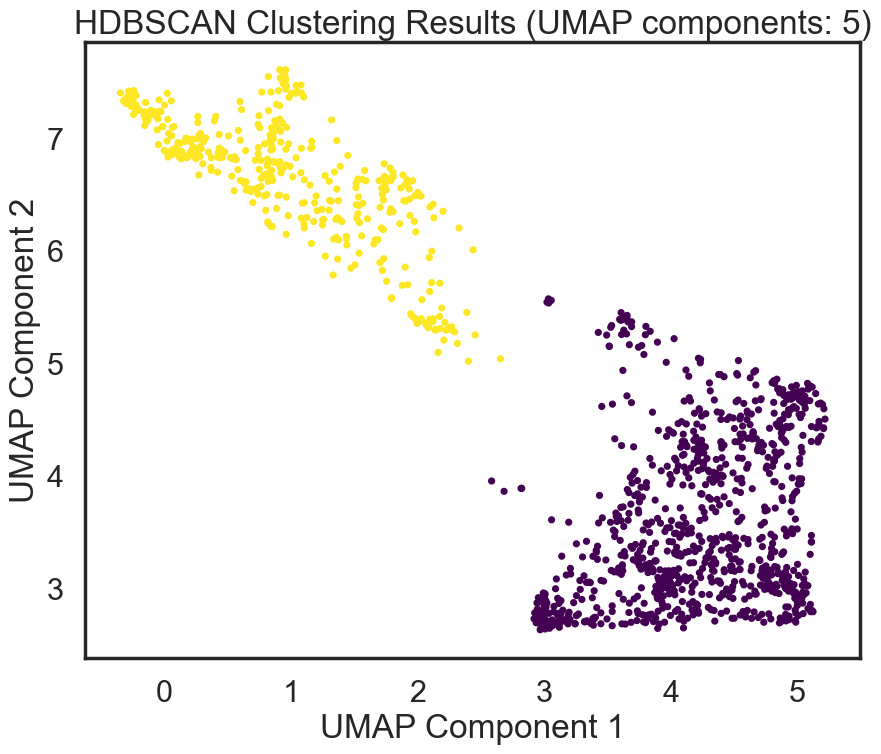

In [270]:

plt.figure(figsize=(10, 8))
plt.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1], c=hdbscan_labels, cmap='viridis', s=10)
plt.title('HDBSCAN Clustering Results (UMAP components: 5)')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.show()

In [271]:
num_noise_points = np.sum(hdbscan_labels == -1)

print(f"Number of Noise Points: {num_noise_points}")

Number of Noise Points: 0
